In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import zipfile

zip_path = "/content/cardata.zip"
extract_path = "/content/car_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [10]:
import glob

csv_files = glob.glob("/content/car_dataset/**/*.csv", recursive=True)

print(csv_files)

['/content/car_dataset/car data.csv']


In [11]:
import pandas as pd

df = pd.read_csv(csv_files[0])

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [13]:
df.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [15]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [16]:
df.shape

(301, 9)

In [17]:
df = df.dropna()

In [18]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [19]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 0.4433 10.32    5.01    0.2094  7.8531  6.712   1.1306  0.6118  0.464
  6.641 ]


In [24]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 Score : 0.9660248711535068
MAE : 0.589304918032787
RMSE : 0.884667707182277


In [28]:
r2 = r2_score(y_test, y_pred)

accuracy_percentage = r2 * 100

print(f"Model Accuracy: {accuracy_percentage:.2f}%")

Model Accuracy: 96.60%


In [25]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

         Feature  Importance
2  Present_Price    0.863716
1           Year    0.058424
3     Driven_kms    0.032492
0       Car_Name    0.032096
6   Transmission    0.009321
5   Selling_type    0.001547
4      Fuel_Type    0.001358
7          Owner    0.001045


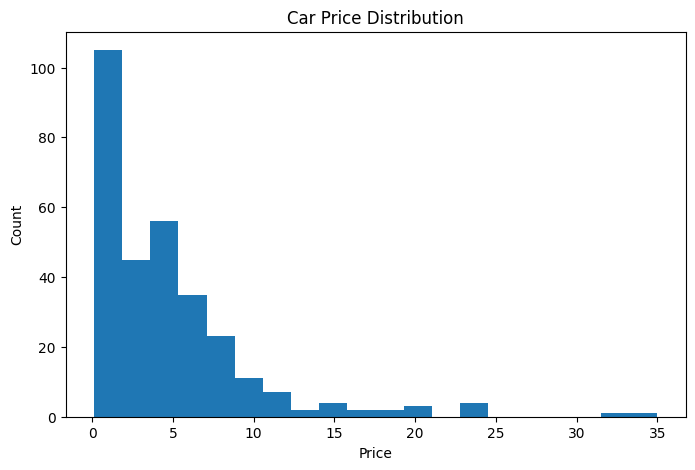

In [29]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=20)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

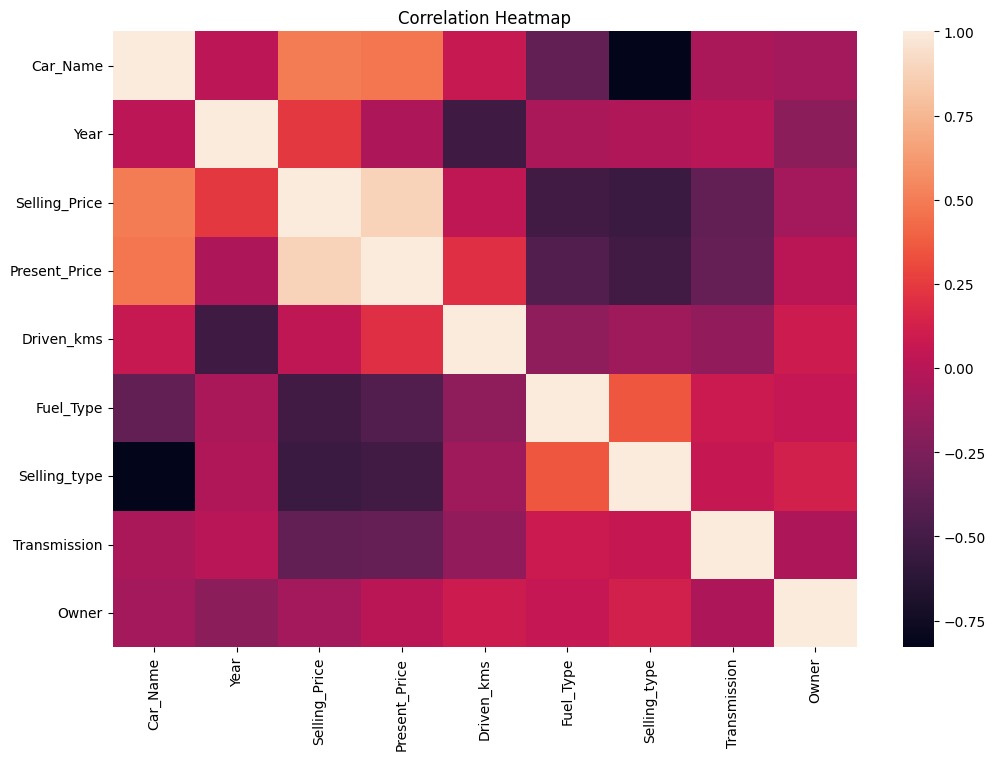

In [30]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)

plt.title("Correlation Heatmap")
plt.show()

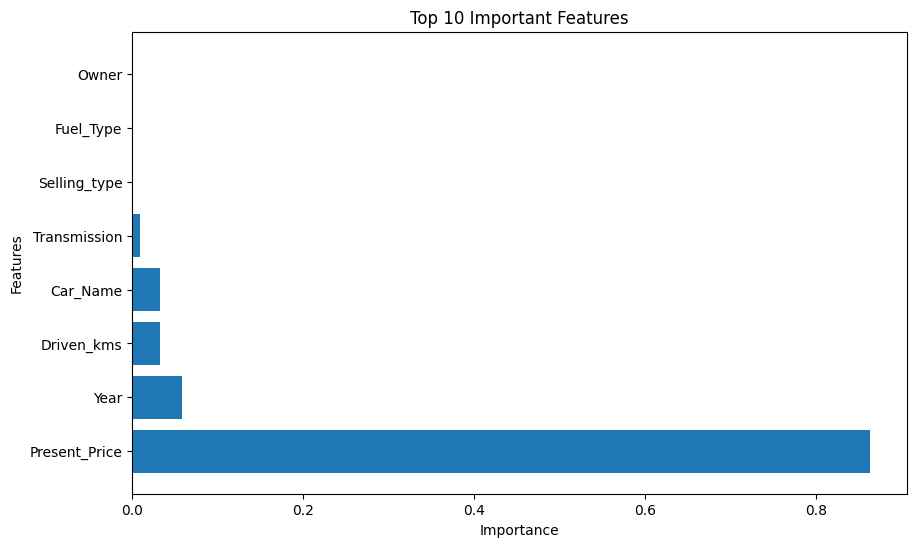

In [26]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()

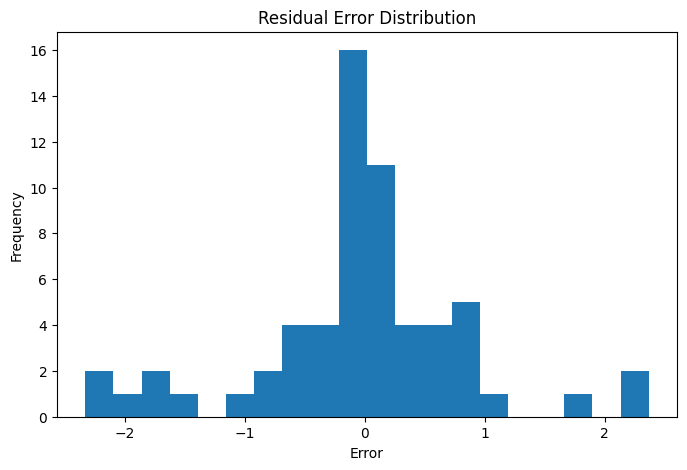

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=20)

plt.title("Residual Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

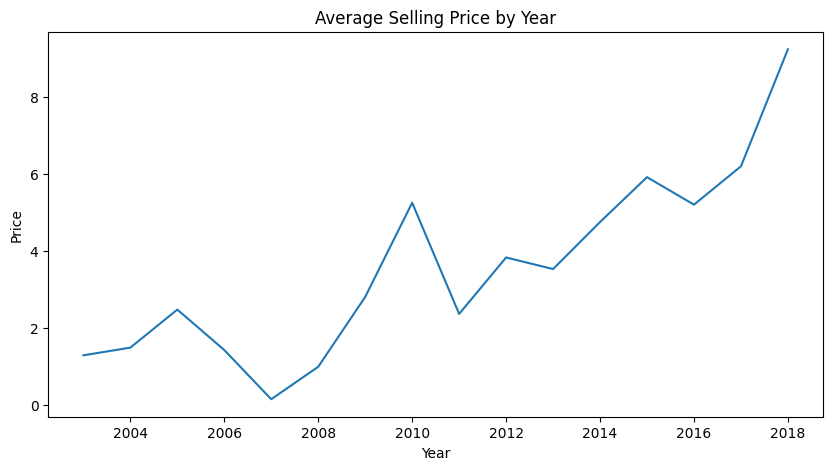

In [33]:
plt.figure(figsize=(10,5))

df.groupby('Year')['Selling_Price'].mean().plot()

plt.title("Average Selling Price by Year")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

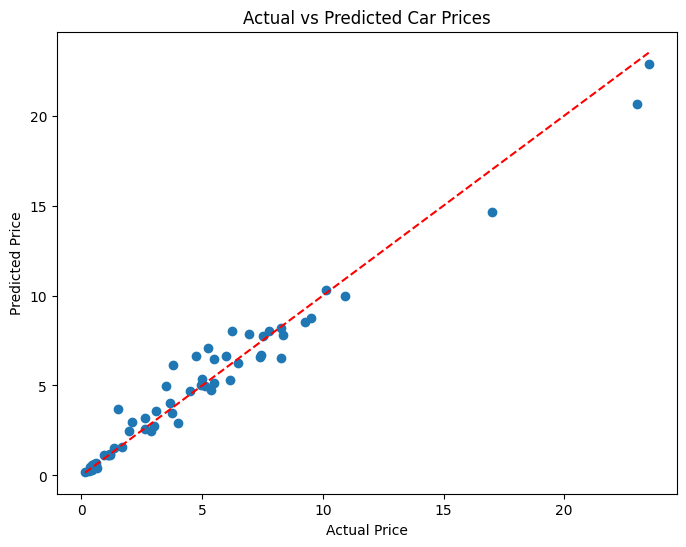

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

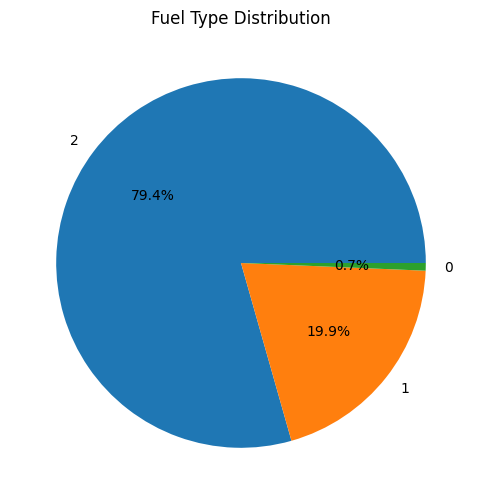

In [34]:
df['Fuel_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()

In [27]:
sample_car = X.iloc[0].values.reshape(1, -1)

predicted_price = model.predict(sample_car)

print("Predicted Price =", predicted_price[0])

Predicted Price = 3.8885000000000036


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [38]:
print("""
Real-World Applications of Machine Learning in Price Prediction

Machine Learning-based Car Price Prediction systems are widely used in the automotive industry.
They help used-car marketplaces estimate fair vehicle prices based on features such as brand,
mileage, fuel type, and age of the vehicle.

Car dealerships can use these predictions to set competitive prices, while buyers can evaluate
whether a vehicle is fairly priced.

Insurance companies and banks can also use price prediction models for vehicle valuation,
loan approvals, and risk assessment.

Platforms such as Cars24, CarDekho, and OLX benefit from automated price estimation systems
to improve decision-making and user experience.
""")


Real-World Applications of Machine Learning in Price Prediction

Machine Learning-based Car Price Prediction systems are widely used in the automotive industry. 
They help used-car marketplaces estimate fair vehicle prices based on features such as brand, 
mileage, fuel type, and age of the vehicle.

Car dealerships can use these predictions to set competitive prices, while buyers can evaluate 
whether a vehicle is fairly priced.

Insurance companies and banks can also use price prediction models for vehicle valuation, 
loan approvals, and risk assessment.

Platforms such as Cars24, CarDekho, and OLX benefit from automated price estimation systems 
to improve decision-making and user experience.

